## 教程一：使用 VarQITE 算法求解分子基态

本教程将详细展示如何利用 变分量子虚时演化（Variational Quantum Imaginary Time Evolution, VarQITE） 算法在活性空间近似下求解 CH₄（甲烷）分子的基态能量。我们将从算法原理讲起，逐步展示 ansatz 结构、哈密顿量构造、求解和可视化。示例中的代码可以直接在 Jupyter Book 环境中运行。

### 1. 算法原理：从虚时间演化到变分模拟

#### 1.1 虚时间薛定谔方程

 对于一个由哈密顿量 $H$ 描述的量子系统，基态$ \left|\psi_{0}\right\rangle $ 是 $H$ 的最小本征态。虚时间演化 提供了一种寻找基态的方法：给定任意初态 $|\psi(0)\rangle $ ，作用非幺正算子 $e^{−Hτ}(τ≥0)$，在 
 $τ→∞$ 极限下，归一化的演化态将逼近基态：  
 $$|\psi(\tau)\rangle=\frac{e^{-H\tau}|\psi(0)\rangle}{\|e^{-H\tau}|\psi(0)\rangle\|}\xrightarrow{\tau\to\infty}|E_0\rangle$$
 该演化的微分形式由 虚时间薛定谔方程 给出：
 $$ \frac{\partial}{\partial\tau}|\psi(\tau)\rangle=-{\left(H-E(\tau)\right)}|\psi(\tau)\rangle,\quad E(\tau)=\frac{\langle\psi(\tau)|H|\psi(\tau)\rangle}{\langle\psi(\tau)|\psi(\tau)\rangle}  \quad(1)$$
 其中 $ -E(\tau)$ 项起归一化作用，保证 $ \frac{d}{d\tau}\langle\psi|\psi\rangle=0$  



#### 1.2 变分模拟：McLachlan 变分原理

VarQITE 的思想是：将态矢量约束在参数化量子电路（ansatz）$|\psi(0)\rangle $ 的流形上，寻找一条参数轨迹  $\theta(\tau)$ ,使得演化速度 $\sum_{j}\frac{\partial|\psi\rangle}{\partial\theta_{j}}\dot{\theta}_{j}$ 尽量接近理想的虚时间变化量 $ -\left(H-E\right)|\psi\rangle$ 。根据 McLachlan 变分原理，我们最小化二者之差的范数：
$$ \delta\|\sum_j\frac{\partial|\psi\rangle}{\partial\theta_j}\dot{\theta}_j+(H-E)|\psi\rangle\|=0$$
这等价于求解一个线性方程组：
$$ \sum_jF_{ij}\dot{\theta}_j=-C_i,\quad i=1,\ldots,m \quad(2)$$
其中 $m$ 为参数总数，  
等式左边的 $ F_{ij}$ 叫做 *量子费舍尔信息矩阵（QFIM）*：
$$ F_{ij}=\Re\left(\langle\partial_i\psi|\partial_j\psi\rangle-\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\right) \quad(3)$$
等式左边的 $C_i$ 叫做 *能量梯度*:
$$C_i=\frac{\partial E}{\partial\theta_i}=\Re\left(\langle\psi|H|\partial_i\psi\rangle-\langle\psi|H|\psi\rangle\langle\psi|\partial_i\psi\rangle\right) \quad(4)$$
因此，每一步 VarQITE 迭代如下：
1. 在当前参数 $θ$ 下，通过量子电路测量得到 $F$ 和 $C$ ；
2. 解线性系统 (2) 得到速度 $ \dot{\theta}$ ;
3. 采用显式欧拉法更新参数:
$$\boldsymbol{\theta}(\tau+\Delta\tau)=\boldsymbol{\theta}(\tau)+\dot{\boldsymbol{\theta}}\Delta\tau$$
4. 重复直至收敛。  
在本框架中，$F$ 和 $C$ 可以通过 参数平移 (parameter shift) 方法 或 自动微分 (autograd) 计算。


### 2. 导入必要的库

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  # 如果 notebook 在 examples/ 下
sys.path.insert(0, PROJECT_ROOT)

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from hyq.backends.Tensorcircuit import TensorCircuitBackend
from hyq.backends.core import QuantumCircuit 
from hyq.ansatz.HEA import HEAAnsatz
from hyq.solvers.var_qite import VarQITESolver
from hyq.chemistry.hamiltonian import Hamiltonian

# 设置环境变量，避免某些系统下的 OpenMP 冲突
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 声明使用的后端类型
os.environ["HYQ_BACKEND"] = "tensorcircuit"

Please first ``pip install -U qiskit`` to enable related functionality in translation module


**TensorCircuitBackend**：基于 TensorCircuit 的量子模拟后端，负责线路模拟、梯度计算等。  
**HEAAnsatz**：硬件高效拟设 (Hardware Efficient Ansatz)，即我们用作参数化电路的 ansatz。  
**VarQITESolver**：VarQITE 求解器，封装了上述变分虚时间演化算法。  
**Hamiltonian**：利用 Psi4 计算分子积分，并生成 qubit 哈密顿量的接口。

### 3. 分子结构与哈密顿量

#### 3.1 甲烷 (CH₄) 几何构型
定义分子的几何位置坐标，其中各参数表示分子中各个原子在三维空间中的空间位置，通常以直角坐标系 $（x, y, z）$描述。单位默认是埃（Å，1Å=10⁻¹⁰米），是化学中常用的分子结构表征方式。  
例如代码中的 $[0.0, 0.0, 0.0], [0.628, 0.628, 0.628]$ 分别表示：  
碳原子（O）位于坐标原点 $（0, 0, 0）$ ；  
氢原子（H）位于 $（0.628, 0.628, 0.628）$ 处；  
这组坐标定义了 甲烷分子 的几何结构（键长、空间取向等）。   
碳原子在原点，四个氢原子按四面体分布：

In [3]:
ch4_geometry = [
    [0.0, 0.0, 0.0],                     #  C
    [0.628, 0.628, 0.628],               #  H1
    [0.628, -0.628, -0.628],             #  H2
    [-0.628, 0.628, -0.628],             #  H3
    [-0.628, -0.628, 0.628]              #  H4
]

#### 3.2 哈密顿量生成与活性空间

原子坐标并不直接决定量子比特的数量，但会通过影响分子的电子结构间接关联到量子比特数量的计算逻辑。量子比特数量主要由分子的电子轨道数量决定，具体流程为：  
1、基组选择：量子化学计算中需选择基组（如默认的 STO-3G），每个原子的基组会产生一定数量的原子轨道（AO）；  
2、分子轨道（MO）：原子轨道通过线性组合形成分子轨道，轨道数量等于基组的总轨道数；  
3、自旋轨道：每个分子轨道包含 α 和 β 两种自旋状态，因此自旋轨道数量为分子轨道数的 2 倍；  
4、映射规则：通过 $Jordan-Wigner$ 等映射方法将自旋轨道的费米子算符转换为量子比特算符，此时量子比特数量等于自旋轨道数量。  

**原子坐标的间接影响：**  
原子坐标通过改变分子的几何结构，影响以下参数（但不改变量子比特数量）：  
核间排斥能：原子位置决定原子核之间的距离，影响哈密顿量中的常数项；  
电子积分（动能、势能）：原子坐标改变会导致电子与核、电子与电子之间的相互作用积分值变化，最终影响哈密顿量中各量子比特算符的系数。  

求解整个 CH₄ 分子的全组态相互作用需要巨大的量子资源。为在当前模拟规模下演示，我们采用 活性空间近似：将低能的核心轨道冻结，只保留活性电子和活性轨道。此处我们选择 2 个活性电子、2 个活性轨道，经 Jordan‑Wigner 变换后映射到 4 个量子比特。

In [4]:
# 实例化哈密顿量对象（将自动调用 Psi4 计算分子积分）
h_obj = Hamiltonian(
    symbols=['C', 'H', 'H', 'H', 'H'],
    geometry=ch4_geometry,
    basis='sto-3g',
    charge=0,
    multiplicity=1
)

# 活性空间处理后得到的 qubit 哈密顿量
hamiltonian_list, n_qubits, n_electrons = h_obj.get_processed_hamiltonian(
    n_active_electrons=2,
    n_active_orbitals=2
)

print(f"任务构建完成: Qubits={n_qubits}, Electrons={n_electrons}")
print(f"哈密顿量项数: {len(hamiltonian_list)}")
print(hamiltonian_list)

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 27
任务构建完成: Qubits=4, Electrons=2
哈密顿量项数: 27
[(-38.67565316015801, 'IIII'), (0.16741488365988957, 'ZIII'), (0.1674148836598896, 'IZII'), (-0.2668902876688517, 'IIZI'), (-0.2668902876688517, 'IIIZ'), (0.13676724242098295, 'ZZII'), (0.007379556143814752, 'XZXI'), (0.007379556143814752, 'YZYI'), (0.10489815847970045, 'ZIZI'), (0.12376996346329175, 'ZIIZ'), (0.12376996346329175, 'IZZI'), (0.007379556143814752, 'IXZX'), (0.007379556143814752, 'IYZY'), (0.10489815847970045, 'IZIZ'), (0.13804363174758946, 'IIZZ'), (-0.001676037399024612, 'ZXZX'), (-0.001676037399024612, 'ZYZY'), (-0.001676037399024612, 'XIXI'), (-0.001676037399024612, 'YIYI'), (-0.01887180498359129, 'XXYY'), (0.01887180498359129, 'XYYX'), (0.01887180498359129, 'YXXY'), (-0.01887180498359129, 'YYXX'), (-0.009055595070773952, 'XZXZ'), (-0.009055595070773952, 'YZYZ'), (-0.009055595070773952, 'IXIX'), (-0.009055595070773952, 'IYIY')]

这里每一项是一个 (系数, Pauli 串) 对，代表 $H=\sum_k\alpha_kP_k$ 

#### 3.3 模拟所需的量子比特数
模拟所需的量子比特数量取决于所选基组的轨道数。
以本教程中 CH4 分子为例（STO-3G 基组）：
- 碳原子 (C) 的原子序数为 6，核外有 6 个电子，
  电子构型为 1s² 2s² 2p²。
  s 能级 (l=0)：只有 1 个轨道（无方向差异）；
  p 能级 (l=1)：有 3 个简并轨道。
  因此碳原子共有 1 (1s) + 1 (2s) + 3 (2p) = 5 个空间轨道。
- 每个氢原子 (H) 的电子构型为 1s¹，只有 1 个 1s 轨道。
  4 个氢原子共提供 4 个空间轨道。
- 总空间轨道数 = 5 (C) + 4 (H) = 9。
- 总自旋轨道数 = 9 × 2 = 18。
若采用全电子、全轨道模拟，需要 18 个量子比特。

然而，分子的低能物理通常只涉及费米能级附近的少数轨道。
活性空间近似通过冻结深层核心轨道和舍弃高能虚轨道，
仅选取少量活性电子和活性轨道，大幅缩减量子比特需求。
本例中我们选取 2 个活性电子、2 个活性轨道，经 $Jordan-Wigner$ 变换后，
所需量子比特数为 2 × 2 = 4（每个空间轨道对应一个量子比特，
不考虑自旋简并，因为实际编码时通常用“奇偶约化”或“布雷维-基塔耶夫变换”
进一步节省资源；在此为简单起见，每个空间轨道仍映射为 1 个量子比特）。

更一般地，元素在 STO-3G 基组下的空间轨道数可依电子构型快速推算：
- H  (1s¹)          -> 1 个轨道
- C  (1s² 2s² 2p²)  -> 1 + 1 + 3 = 5 个轨道
- N  (1s² 2s² 2p³)  -> 1 + 1 + 3 = 5 个轨道
- O  (1s² 2s² 2p⁴)  -> 1 + 1 + 3 = 5 个轨道
- Ne (1s² 2s² 2p⁶)  -> 1 + 1 + 3 = 5 个轨道

### 4. 硬件高效拟设 (Hardware Efficient Ansatz, HEA)
HEA 是目前变分量子算法中最常用的 ansatz 结构之一，其设计原则是 用尽可能少的硬件操作实现强纠缠。基本结构如下：  
**旋转层**：每个量子比特施加一个含参数的 $R_y(\theta)\text{ 门(}R_y(\theta)=e^{-i\theta Y/2})$  
**纠缠层**：在相邻量子比特之间施加 CNOT 门，形成环状或线形连接。此处使用线性链（所有 $(i,i+1)$ 对）。  
**重复上述“旋转+纠缠”模块**共 $d$ 次（称为 深度），最后再额外施加一层 $R_y$ 旋转。  

总参数数目为 $n_\mathrm{qubits}\times(d+1)$  

以下代码打印一个 $n_{qubits}=4、d=2$ 的 HEA 电路，以便直观理解：  

In [5]:
n_qubits = 4
depth = 2
total_params = n_qubits * (depth + 1)

# 生成示例参数
params = [0.1, 0.2, 0.3, 0.4,   # 第0层旋转
          0.5, 0.6, 0.7, 0.8,   # 第1层旋转
          0.9, 1.0, 1.1, 1.2]   # 最终层旋转

# 初始化电路
qc = QuantumCircuit(n_qubits, name="HEA_Manual")

# 逐层构建
param_idx = 0
for d in range(depth):
    # 旋转层
    for i in range(n_qubits):
        qc.ry(i, params[param_idx])
        param_idx += 1
    # 纠缠层 
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)

# 最终旋转层
for i in range(n_qubits):
    qc.ry(i, params[param_idx])
    param_idx += 1

# 打印电路图
print("[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):")
print(qc.draw(output='text', fold=-1))

[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):
     ┌─────────┐     ┌─────────┐                      ┌─────────┐                    
q_0: ┤ Ry(0.1) ├──■──┤ Ry(0.5) ├────────────────■─────┤ Ry(0.9) ├────────────────────
     ├─────────┤┌─┴─┐└─────────┘┌─────────┐   ┌─┴─┐   └─────────┘┌───────┐           
q_1: ┤ Ry(0.2) ├┤ X ├─────■─────┤ Ry(0.6) ├───┤ X ├────────■─────┤ Ry(1) ├───────────
     ├─────────┤└───┘   ┌─┴─┐   └─────────┘┌──┴───┴──┐   ┌─┴─┐   └───────┘┌─────────┐
q_2: ┤ Ry(0.3) ├────────┤ X ├────────■─────┤ Ry(0.7) ├───┤ X ├───────■────┤ Ry(1.1) ├
     ├─────────┤        └───┘      ┌─┴─┐   ├─────────┤   └───┘     ┌─┴─┐  ├─────────┤
q_3: ┤ Ry(0.4) ├───────────────────┤ X ├───┤ Ry(0.8) ├─────────────┤ X ├──┤ Ry(1.2) ├
     └─────────┘                   └───┘   └─────────┘             └───┘  └─────────┘


### 5. 初始化后端与 Anstaz

In [6]:
# 创建 TensorCircuit 后端
backend = TensorCircuitBackend()

# 构建 HEA ansatz，深度为 3
ansatz = HEAAnsatz(n_qubits=n_qubits, depth=3)

# 随机初始化参数（或使用一组预先设定的参数）
init_params = torch.tensor(
    [-1.0537, -0.0093,  0.1670,  0.2519, -1.1550,  0.0890,  0.4244, -0.4072,
      0.3096,  0.0074,  0.0569, -0.6634, -0.5790,  0.5391,  0.1754,  0.3254],
    dtype=torch.float64
)

print("初始参数形状:", init_params.shape)

初始参数形状: torch.Size([16])


### 6. 执行 VarQITE 演化

现在调用 **VarQITESolver** 进行求解。主要参数说明：  
**total_tau**	:总虚时间演化时长。值越大，收敛越充分。  
**delta_tau** 	:单步时间步长。  
**mode**     	:'autograd' 使用自动微分计算 QFIM 与梯度；'parameter_shift' 使用参数平移法则。

In [7]:
var_solver = VarQITESolver(backend)

final_e, final_params, energy_history, _ = var_solver.solve(
    ansatz,
    init_params,
    hamiltonian_list,
    total_tau=10.0,
    delta_tau=0.05,
    mode='autograd'
)

print(f"求解结束。最终能量: {energy_history[-1]:.6f} Hartree")

--- VarQITE Start (Mode=autograd, Total Tau=10.0, dt=0.05) ---
Step 0: Energy = -38.718087 (Time: 0.2250s)
Step 10: Energy = -39.150861 (Time: 0.1780s)
Step 20: Energy = -39.466150 (Time: 0.1739s)
Step 30: Energy = -39.615719 (Time: 0.1640s)
Step 40: Energy = -39.678400 (Time: 0.1770s)
Step 50: Energy = -39.705621 (Time: 0.1500s)
Step 60: Energy = -39.718145 (Time: 0.1530s)
Step 70: Energy = -39.724120 (Time: 0.1590s)
Step 80: Energy = -39.727039 (Time: 0.1440s)
Step 90: Energy = -39.728508 (Time: 0.1560s)
Step 100: Energy = -39.729257 (Time: 0.1810s)
Step 110: Energy = -39.729640 (Time: 0.4230s)
Step 120: Energy = -39.729839 (Time: 0.1650s)
Step 130: Energy = -39.729944 (Time: 0.1670s)
Step 140: Energy = -39.729999 (Time: 0.1620s)
Step 150: Energy = -39.730029 (Time: 0.2210s)
Step 160: Energy = -39.730046 (Time: 0.2900s)
Step 170: Energy = -39.730055 (Time: 0.1480s)
Step 180: Energy = -39.730060 (Time: 0.1511s)
Step 190: Energy = -39.730063 (Time: 0.1510s)
Step 199: Energy = -39.73006

能量从初始约 −38.7 哈特里快速下降到约 −39.73 哈特里，趋近该活性空间下的精确基态能量。

### 7. 结果可视化

绘制能量随演化步数（ $τ$ 的进展）变化的收敛曲线：

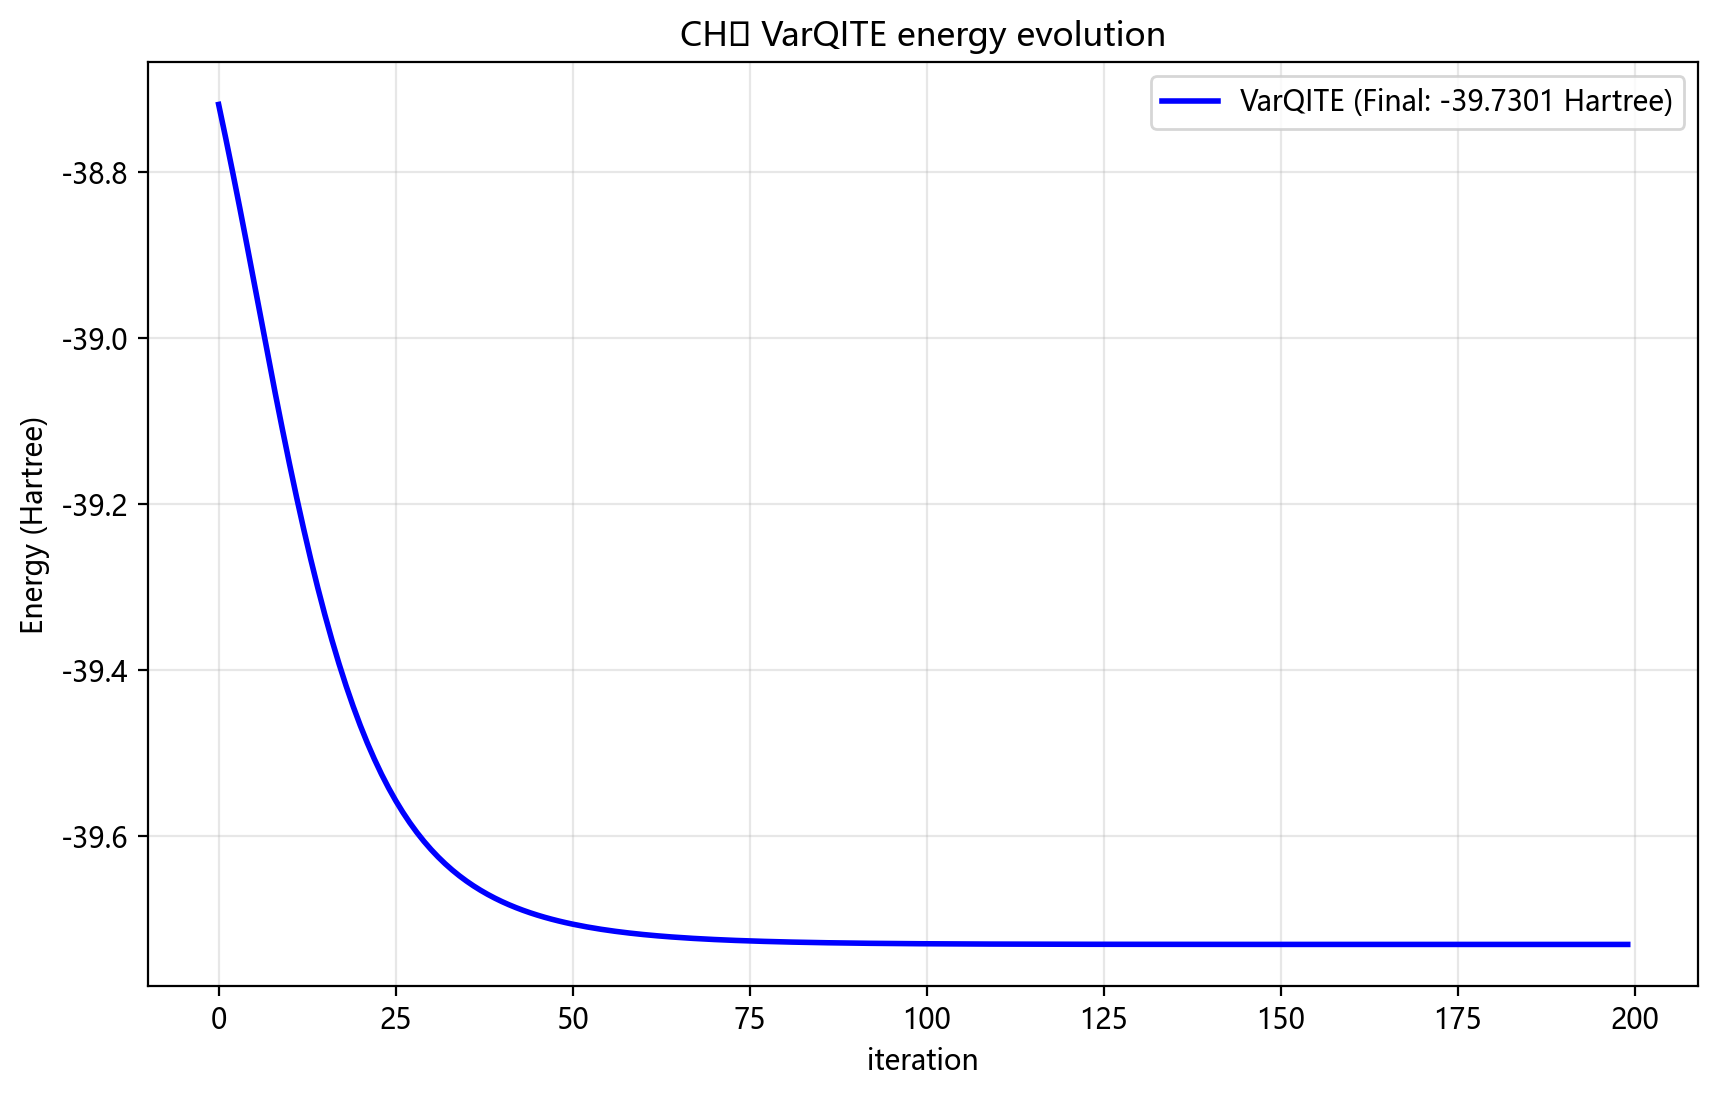

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(energy_history, label=f'VarQITE (Final: {energy_history[-1]:.4f} Hartree)',
         color='b', linewidth=2)
plt.title("CH₄ VarQITE energy evolution")
plt.xlabel("iteration")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 8. 小结

本教程以 CH₄ 分子为例，介绍了 VarQITE 算法的核心原理，并通过代码演示了如何：  
1. 利用 **Hamiltonian** 类生成 qubit 哈密顿量；  
2. 构造硬件高效拟设 (HEA) 并可视化其电路结构；
3. 使用 **VarQITESolver** 在自动微分模式下运行虚时间演化；
4. 观察能量收敛过程。  

VarQITE 是一种无需经典优化器的基态求解方法，通过模拟虚时间演化自然趋向基态，在某些问题中比传统 VQE 具有更稳定的收敛性质。

在后续示例中，我们将探索其他 ansatz 结构（如 UCCSD）、其他求解器（如 VQE、RQITE、SSQITE）以及如何在激发态空间中进行并行优化。

### 9. 参考文献
[1] McArdle, S., Jones, T., Endo, S. et al. Variational ansatz-based quantum simulation of imaginary time evolution. npj Quantum Inf 5, 75 (2019).